# 10.6.2 滚动求解与预测失配

## 学习目标与先修知识

每步只执行首个行动，比较预测与实际轨迹（trajectory）并记录失败。

先修：10.6.1小型硬约束问题、10.4部分状态（state）估计及第6.5章模型（model）失配。

## 具体问题

上一步预测（one-step-ahead prediction）未来两步都可行，下一步的实际状态却受扰动偏离了预测。控制器应执行旧计划剩下的部分，还是用新状态重新求解？如何显示求解失败？

In [1]:
import math
import itertools
import ast
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

同一初态下先计算一次两步计划；随后人为给出与预测首步不同的实际状态。

In [2]:
print("在x=0且动作u=1时，名义下一状态：",0.+1.)

在x=0且动作u=1时，名义下一状态： 1.0


## 模型假设

仍用10.6.1的离散行动MPC，名义模型x_next=x+u。实际对象为 $x_{next}=0.92x+u+0.1$，所以预测和实际不同。为隔离滚动机制，此节直接观测（observation）实际标量状态；若只有部分读数，必须先声明估计接口。约束只在名义预测轨迹中施加，实际轨迹的违约另行报告。

## 数学解释与推导

在时刻t，估计或读出当前状态 $\hat x_t$，求长度N的最优预测行动序列 $(u^*_{t|t},\ldots,u^*_{t+N-1|t})$。实际只执行 $u^*_{t|t}$；到时刻t+1，使用新可用信息重新求解。若真实状态为 $x_{t+1}=a_{real}x_t+bu_t+d_t$，而预测用 $a_{model}$，则一步偏差为 $(a_{real}-a_{model})x_t+d_t$，一般不为零。

名义可行性不等于实际硬约束永远满足，也不保证下一次求解可行。求解超时或不可行必须记录状态；备用策略只有在单独验证适用域后才可投入使用。完整状态反馈（feedback）若来自教学模拟真值，不能与实际部分观测控制混称同一信息条件。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def discrete_mpc(state, a, b, target, q, r, terminal, actions, horizon, lower, upper):
    """Exact enumeration of a small *discrete-action* MPC, not continuous MPC."""
    best = None
    for sequence in itertools.product(actions, repeat=horizon):
        x = state
        cost = 0.0
        path = [x]
        for u in sequence:
            cost += q * (x - target) ** 2 + r * u * u
            x = a * x + b * u
            path.append(x)
            if not lower <= x <= upper:
                break
        else:
            cost += terminal * (x - target) ** 2
            candidate = (cost, sequence, path)
            if best is None or candidate[:2] < best[:2]:
                best = candidate
    if best is None:
        return 'infeasible', None, None, []
    cost, sequence, path = best
    return 'optimal', sequence[0], cost, path


def receding_actions(initial, a, b, target, q, r, terminal, actions, horizon, lower, upper, steps):
    state = initial
    states = [state]
    applied = []
    statuses = []
    for _ in range(steps):
        status, action, _, _ = discrete_mpc(state, a, b, target, q, r, terminal,
                                            actions, horizon, lower, upper)
        statuses.append(status)
        if status != 'optimal':
            break
        applied.append(action)
        state = a * state + b * action
        states.append(state)
    return states, applied, statuses

## 对照实验

并行比较名义模型内滚动轨迹与每步使用新实际状态的失配轨迹；画出每次真实执行输入（input），记录每次求解状态和实际超限次数。

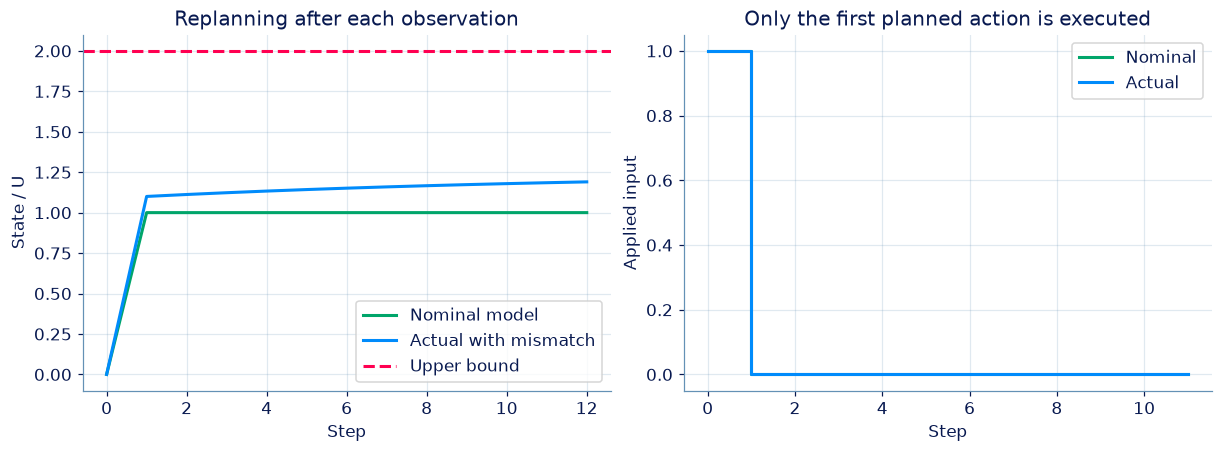

求解状态： ['optimal', 'optimal', 'optimal', 'optimal', 'optimal', 'optimal', 'optimal', 'optimal', 'optimal', 'optimal', 'optimal', 'optimal'] ；实际超限步数： 0


In [4]:
common=dict(a=1.,b=1.,target=1.,q=1.,r=.1,terminal=2.,actions=[-1.,0.,1.],horizon=2,lower=-1.,upper=2.)
nominal,planned,statuses=receding_actions(0.,**common,steps=12)
actual=[0.];applied=[];solver_status=[]
for _ in range(12):
    status,u,cost,path=discrete_mpc(actual[-1],**common)
    solver_status.append(status)
    if status!='optimal':break
    applied.append(u);actual.append(.92*actual[-1]+u+.1)
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(nominal,label='Nominal model',color=GREEN);axes[0].plot(actual,label='Actual with mismatch',color=BLUE);axes[0].axhline(2,color=PINK,ls='--',label='Upper bound')
axes[0].set(xlabel='Step',ylabel='State / U',title='Replanning after each observation');axes[0].legend()
axes[1].step(range(len(planned)),planned,where='post',label='Nominal',color=GREEN);axes[1].step(range(len(applied)),applied,where='post',label='Actual',color=BLUE)
axes[1].set(xlabel='Step',ylabel='Applied input',title='Only the first planned action is executed');axes[1].legend();plt.show()
print('求解状态：',solver_status,'；实际超限步数：',sum(not -1<=x<=2 for x in actual[1:]))

## 结果解释

失配系统不断用新实际状态重新求解，因此之后的输入可以偏离最初计划。比较实际状态与约束，可以检查模型失配是否造成越界；优化器报告的最优解针对的是名义预测。

### 独立核对

独立检查名义轨迹确由每一步第一个最优行动推进；失配轨迹按真实方程重算，并验证返回序列、状态和求解记录长度关系。

In [5]:
for i,u in enumerate(planned):np.testing.assert_allclose(nominal[i+1],nominal[i]+u)
for i,u in enumerate(applied):np.testing.assert_allclose(actual[i+1],.92*actual[i]+u+.1)
assert len(nominal)==len(planned)+1 and len(actual)==len(applied)+1
assert len(statuses)>=len(planned) and len(solver_status)>=len(applied)
print('实际与名义轨迹分别按其声明的模型核对。')

实际与名义轨迹分别按其声明的模型核对。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/10-06-%E5%B8%A6%E7%BA%A6%E6%9D%9F%E7%9A%84%20MPC/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：逐时刻重新求解

对确定性标量模型（model）重复题定离散行动MPC。每次只执行最优序列第一项；不可行时停止，并保留失败状态（state），不自行补造控制动作。

**函数与代码模板**

```python
def solve(
    state: float,
    a: float,
    b: float,
    target: float,
    q: float,
    r: float,
    terminal: float,
    actions: list[float],
    horizon: int,
    lower: float,
    upper: float,
    steps: int,
) -> tuple[list[float], list[float], list[str]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `float` | 当前状态。 | U |
| `a` | `float` | 离散保持系数。 | 1 |
| `b` | `float` | 输入（input）作用系数。 | U/输入 |
| `target` | `float` | 目标状态。 | U |
| `q` | `float` | 阶段跟踪权重，非负。 | 代价/U² |
| `r` | `float` | 输入权重，非负。 | 代价/输入² |
| `terminal` | `float` | 终端跟踪权重，非负。 | 代价/U² |
| `actions` | `list[float]` | 允许的离散输入，已升序且互异。 | 输入单位 |
| `horizon` | `int` | 预测步数。 | 步 |
| `lower` | `float` | 预测状态下界。 | U |
| `upper` | `float` | 预测状态上界。 | U |
| `steps` | `int` | 最多执行的实际步数。 | 步 |

**返回值**

按以下顺序返回元组：(states, applied, statuses)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 含初态及每个实际执行后状态。 | U |
| `applied` | `list[float]` | 实际执行输入。 | 输入单位 |
| `statuses` | `list[str]` | 每次求解状态，含最后一次不可行。 | 不适用 |

**计算规则**

逐次调用与10.6.1相同的求解问题；成功则只执行首步并以真实模型更新，失败立即停止。

**约束与边界**

- 沿用10.6.1输入范围；0≤steps≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 当前状态。 | 0 | U |
| a | 离散保持系数。 | 1 | 1 |
| b | 输入（input）作用系数。 | 1 | U/输入 |
| target | 目标状态。 | 1 | U |
| q | 阶段跟踪权重，非负。 | 1 | 代价/U² |
| r | 输入权重，非负。 | 0.1 | 代价/输入² |
| terminal | 终端跟踪权重，非负。 | 2 | 代价/U² |
| actions | 允许的离散输入，已升序且互异。 | [-1.0, 0.0, 1.0] | 输入单位 |
| horizon | 预测步数。 | 2 | 步 |
| lower | 预测状态下界。 | -1 | U |
| upper | 预测状态上界。 | 2 | U |
| steps | 最多执行的实际步数。 | 4 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = 0.0
a = 1.0
b = 1.0
target = 1.0
q = 1.0
r = 0.1
terminal = 2.0
actions = [-1.0, 0.0, 1.0]
horizon = 2
lower = -1.0
upper = 2.0
steps = 4

result = solve(state, a, b, target, q, r, terminal, actions, horizon, lower, upper, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 含初态及每个实际执行后状态。 | [0.0, 1.0, 1.0, 1.0, 1.0] | U |
| applied | 实际执行输入。 | [1.0, 0.0, 0.0, 0.0] | 输入单位 |
| statuses | 每次求解状态，含最后一次不可行。 | ['optimal', 'optimal', 'optimal', 'optimal'] | 不适用 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.0, 1.0, 1.0, 1.0, 1.0],
                   [1.0, 0.0, 0.0, 0.0],
                   ['optimal',
                    'optimal',
                    'optimal',
                    'optimal'])
```

**样例解释**

每一步都重新计算；预测的第二步计划可能在新读数或实际模型偏差后改变。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：逐时刻重新求解](http://127.0.0.1:8000/chapters/10-06-%E5%B8%A6%E7%BA%A6%E6%9D%9F%E7%9A%84%20MPC/practice/?question=p10-receding-trajectory)

### 第 2 题 · 单项选择题：预测轨迹不等于实际轨迹

已知模型（model）预测下一状态（state）为1.0 U，实际系统受到未建模扰动，读数为1.3 U。下一时刻合理的做法是什么？

- **A.** 记录偏差，用新的可用观测（observation）或估计重新求解，并检查约束。
- **B.** 继续把旧预测1.0当作真实状态。
- **C.** 删去这个场景以维护好看的平均误差。
- **D.** 只要上一步预测（one-step-ahead prediction）可行，当前约束自动安全。

[作答：预测轨迹不等于实际轨迹](http://127.0.0.1:8000/chapters/10-06-%E5%B8%A6%E7%BA%A6%E6%9D%9F%E7%9A%84%20MPC/practice/?question=p10-prediction-vs-reality)

### 第 3 题 · 单项选择题：备用控制需要验证

求解超时后采用备用输入（input）。哪项表述正确？

- **A.** 备用策略的适用状态（state）范围与约束应单独检验。
- **B.** 备用输入来自上一步就自动安全。
- **C.** 超时不必计入失败统计。
- **D.** 只要代价函数凸就永不超时。

[作答：备用控制需要验证](http://127.0.0.1:8000/chapters/10-06-%E5%B8%A6%E7%BA%A6%E6%9D%9F%E7%9A%84%20MPC/practice/?question=p10-fallback-domain)

### 第 4 题 · 单项选择题：MPC 起点的状态从哪里来

只有读数 y、没有完整状态（state） x 的控制任务中，MPC 如何得到初始状态？

- **A.** 使用给定的估计器或可用信息，并传播估计误差影响。
- **B.** 在教学模拟中直接偷取隐藏真值却称公平比较。
- **C.** 令未观测（observation）分量默认为零而不说明。
- **D.** 只要MPC优化精确，估计误差不再重要。

[作答：MPC 起点的状态从哪里来](http://127.0.0.1:8000/chapters/10-06-%E5%B8%A6%E7%BA%A6%E6%9D%9F%E7%9A%84%20MPC/practice/?question=p10-estimate-interface)

**进一步阅读**

[MIT Underactuated Robotics：Linear Quadratic Regulators](https://underactuated.mit.edu/lqr.html)：动态规划、LQR 与有约束控制的边界；本教材的离散行动例由此处的教学目标独立设计。